In [6]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from mindquantum.algorithm.library import amplitude_encoder

project_path = pathlib.Path.cwd().parent.parent.parent
# print("project path:", project_path)


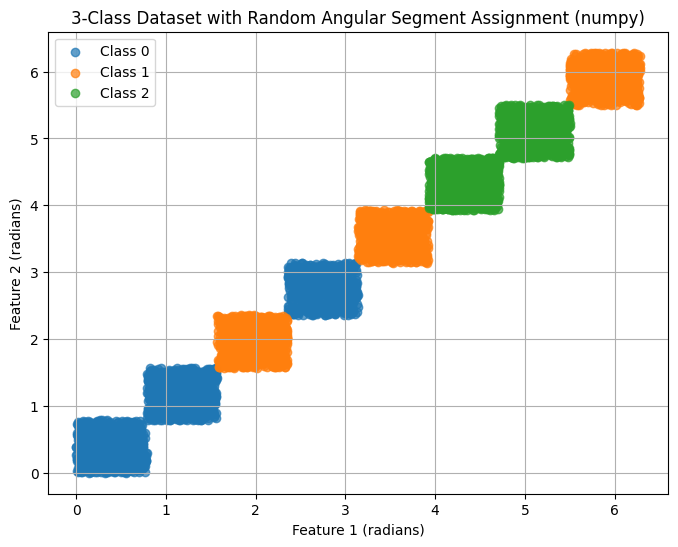

In [7]:
# 用numpy实现并固定seed
np.random.seed(42)

n_train_per_class = 2000  # 训练集每类2000个样本
n_test_per_class = 1000   # 测试集每类1000个样本
n_features = 4

# 将[0, 2π]平均分成8份
segment_size = 2 * np.pi / 8
all_segments = [(i * segment_size, (i + 1) * segment_size) for i in range(8)]

# 随机分配段给三个类别，固定分配种子
np.random.seed(123)
segment_indices = np.random.permutation(8)

class0_segment_indices = segment_indices[:3]
class1_segment_indices = segment_indices[3:6]
class2_segment_indices = segment_indices[6:8]

class0_ranges = [all_segments[i] for i in class0_segment_indices]
class1_ranges = [all_segments[i] for i in class1_segment_indices]
class2_ranges = [all_segments[i] for i in class2_segment_indices]

def generate_class_data_multiple_ranges(angle_ranges, n_samples, n_features):
    samples_per_range = n_samples // len(angle_ranges)
    remaining_samples = n_samples % len(angle_ranges)
    
    data_list = []
    for i, (start, end) in enumerate(angle_ranges):
        current_samples = samples_per_range + (remaining_samples if i == len(angle_ranges) - 1 else 0)
        range_data = np.random.uniform(start, end, size=(current_samples, n_features))
        data_list.append(range_data)
    return np.vstack(data_list)

X_train_class0 = generate_class_data_multiple_ranges(class0_ranges, n_train_per_class, n_features)
X_train_class1 = generate_class_data_multiple_ranges(class1_ranges, n_train_per_class, n_features)
X_train_class2 = generate_class_data_multiple_ranges(class2_ranges, n_train_per_class, n_features)

X_test_class0 = generate_class_data_multiple_ranges(class0_ranges, n_test_per_class, n_features)
X_test_class1 = generate_class_data_multiple_ranges(class1_ranges, n_test_per_class, n_features)
X_test_class2 = generate_class_data_multiple_ranges(class2_ranges, n_test_per_class, n_features)

x_train = np.vstack([X_train_class0, X_train_class1, X_train_class2])
y_train = np.hstack([np.zeros(n_train_per_class), np.ones(n_train_per_class), np.full(n_train_per_class, 2)])

x_test = np.vstack([X_test_class0, X_test_class1, X_test_class2])
y_test = np.hstack([np.zeros(n_test_per_class), np.ones(n_test_per_class), np.full(n_test_per_class, 2)])

assert x_train.shape[0] == 6000, f"Training set should have 6000 samples, got {x_train.shape[0]}"
assert x_test.shape[0] == 3000, f"Test set should have 3000 samples, got {x_test.shape[0]}"

# 打乱训练数据顺序
np.random.seed(100)
train_indices = np.random.permutation(len(x_train))
x_train = x_train[train_indices]
y_train = y_train[train_indices].astype(int)

# 打乱测试数据顺序
np.random.seed(101)
test_indices = np.random.permutation(len(x_test))
x_test = x_test[test_indices]
y_test = y_test[test_indices].astype(int)

# 可视化前两个维度
plt.figure(figsize=(8, 6))
for i in range(3):
    plt.scatter(x_train[y_train == i, 0], x_train[y_train == i, 1], label=f'Class {i}', alpha=0.7)
plt.title('3-Class Dataset with Random Angular Segment Assignment (numpy)')
plt.xlabel('Feature 1 (radians)')
plt.ylabel('Feature 2 (radians)')
plt.legend()
plt.grid(True)
plt.show()



In [10]:
def save_dataset(x_train, y_train, x_test, y_test, data_type, datasets_path):
    os.makedirs(f"{datasets_path}/{data_type}", exist_ok=True)
    n_qubits = 4
    n_layers = 1
    n_train_samples = len(y_train)
    n_test_samples = len(y_test)
    x_train = x_train.reshape(n_train_samples, n_qubits)
    x_test = x_test.reshape(n_test_samples, n_qubits)
    np.save(f"{datasets_path}/{data_type}/x_train_qubit_{n_qubits}_layer_{n_layers}_samples_{n_train_samples}.npy", x_train)
    np.save(f"{datasets_path}/{data_type}/y_train_qubit_{n_qubits}_layer_{n_layers}_samples_{n_train_samples}.npy", y_train)
    np.save(f"{datasets_path}/{data_type}/x_test_qubit_{n_qubits}_layer_{n_layers}_samples_{n_test_samples}.npy", x_test)
    np.save(f"{datasets_path}/{data_type}/y_test_qubit_{n_qubits}_layer_{n_layers}_samples_{n_test_samples}.npy", y_test)

In [11]:
data_type = 'classification_012'
datasets_path = project_path / 'datasets'
save_dataset(x_train,y_train,x_test,y_test,data_type=data_type,datasets_path=datasets_path)
